In [1]:
# =========================
# CELL 1 8
# =========================
import warnings
warnings.filterwarnings('ignore')
from itertools import product
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False
RANDOM_STATE = 42
DATA_PATH = '/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv'
TARGET = 'fail'
TEST_SIZE = 0.15
VALID_SIZE_OF_REMAINDER = 0.17647058823529413
INSPECT_COST = 10.0
MISSED_FAILURE_COST = 500.0
CAPACITY_STEP = 5
ROW_CHECK_COST = INSPECT_COST
BASE_ROW_MISSED_LOSS = MISSED_FAILURE_COST
ROW_VALUE_RECOVERY_RATE = 1.0
ROW_VALUE_SEGMENTS = 3
ROW_VALUE_TOP_FEATURES = 5
PATHS = {'queue': 'locked_test_queue.csv', 'summary': 'locked_test_summary.csv', 'candidate': 'candidate_results.csv', 'confusion': 'locked_test_confusion_matrix.csv', 'feature_importance': 'winning_model_feature_importance.csv', 'threshold_stability': 'threshold_stability_check.csv', 'baseline': 'baseline_comparison.csv', 'cost_sensitivity': 'cost_recovery_sensitivity.csv', 'leakage_check': 'leakage_check.csv', 'stage1': 'stage1_ml_quality_results.csv', 'stage2': 'stage2_threshold_capture_results.csv', 'stage3': 'stage3_final_policy_results.csv'}
MODEL_NAMES = ['logistic_regression', 'extra_trees', 'gradient_boosting', 'xgboost']
CALIBRATION_METHODS = ['none', 'sigmoid', 'temperature']
WEIGHT_STYLES = ['none', 'balanced_x0.75', 'balanced', 'balanced_x1.25', 'balanced_x1.5']
WEIGHT_MULTIPLIERS = {'balanced_x0.75': 0.75, 'balanced': 1.0, 'balanced_x1.25': 1.25, 'balanced_x1.5': 1.5}
THRESHOLD_MULTIPLIERS = [0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15]
INSPECT_COST_MULTIPLIERS = [0.5, 1.0, 1.5]
MISSED_COST_MULTIPLIERS = [0.5, 1.0, 1.5]
RECOVERY_RATES = [0.6, 0.8, 1.0]
RANDOM_BASELINE_ROUNDS = 300
PERMUTATION_SAMPLE_N = 600

def clip_probs(p: np.ndarray) -> np.ndarray:
    return np.clip(np.asarray(p, dtype=float), 1e-06, 1.0 - 1e-06)

def safe_divide(numerator: float, denominator: float) -> float:
    return float(numerator / max(float(denominator), 1.0))

def load_dataset(path: str, target: str) -> Tuple[pd.DataFrame, pd.Series]:
    data = pd.read_csv(path).drop_duplicates().reset_index(drop=True)
    if target not in data.columns:
        raise ValueError(f'Missing target column: {target}')
    feature_cols = [c for c in data.columns if c != target and pd.api.types.is_numeric_dtype(data[c])]
    if not feature_cols:
        raise ValueError('No numeric feature columns found.')
    return (data[feature_cols].copy(), data[target].astype(int).copy())

def split_dataset(X, y):
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=VALID_SIZE_OF_REMAINDER, stratify=y_temp, random_state=RANDOM_STATE)
    return (X_train, X_valid, X_test, y_train, y_valid, y_test)

def make_class_weight(style: str, y_train: pd.Series) -> Optional[Dict[int, float]]:
    if style == 'none':
        return None
    pos_count = int(y_train.sum())
    neg_count = len(y_train) - pos_count
    return {0: 1.0, 1: float(WEIGHT_MULTIPLIERS[style] * neg_count / max(pos_count, 1))}

def build_estimator(model_name: str, class_weight: Optional[Dict[int, float]]) -> Pipeline:
    imputer = ('impute', SimpleImputer(strategy='median'))
    if model_name == 'logistic_regression':
        model = LogisticRegression(max_iter=3000, solver='lbfgs', class_weight=class_weight, random_state=RANDOM_STATE)
        return Pipeline([imputer, ('scale', StandardScaler()), ('model', model)])
    if model_name == 'extra_trees':
        model = ExtraTreesClassifier(n_estimators=280, min_samples_leaf=2, n_jobs=-1, class_weight=class_weight, random_state=RANDOM_STATE)
        return Pipeline([imputer, ('model', model)])
    if model_name == 'gradient_boosting':
        model = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, max_leaf_nodes=31, min_samples_leaf=20, class_weight=class_weight, random_state=RANDOM_STATE)
        return Pipeline([imputer, ('model', model)])
    if model_name == 'xgboost':
        if not HAS_XGBOOST:
            raise ImportError('xgboost is not installed')
        model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0, objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=1.0 if class_weight is None else float(class_weight[1] / class_weight[0]))
        return Pipeline([imputer, ('model', model)])
    raise ValueError(f'Unknown model: {model_name}')

def prob_to_logit(probabilities: np.ndarray) -> np.ndarray:
    p = clip_probs(probabilities)
    return np.log(p / (1.0 - p))

def logit_to_prob(logits: np.ndarray) -> np.ndarray:
    return clip_probs(1.0 / (1.0 + np.exp(-np.asarray(logits, dtype=float))))

def fit_temperature_value(y_true: pd.Series, probabilities: np.ndarray) -> float:
    y = np.asarray(y_true, dtype=int)
    logits = prob_to_logit(probabilities)
    temperatures = np.unique(np.r_[np.linspace(0.25, 2.0, 36), np.linspace(2.1, 6.0, 40)])
    best_t, best_loss = (1.0, np.inf)
    for t in temperatures:
        p = logit_to_prob(logits / float(t))
        loss = -float(np.mean(y * np.log(p) + (1 - y) * np.log(1.0 - p)))
        if loss < best_loss:
            best_t, best_loss = (float(t), loss)
    return best_t

class ProbabilityCalibratedModel:

    def __init__(self, base_model, calibration_method: str, temperature: float=1.0):
        self.base_model = base_model
        self.calibration_method = calibration_method
        self.temperature = float(temperature)

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        raw_prob = clip_probs(self.base_model.predict_proba(X)[:, 1])
        if self.calibration_method == 'none':
            p = raw_prob
        elif self.calibration_method == 'temperature':
            p = logit_to_prob(prob_to_logit(raw_prob) / self.temperature)
        else:
            raise ValueError(f'Unsupported wrapper calibration method: {self.calibration_method}')
        return np.column_stack([1.0 - p, p])

def calibration_cv_folds(y_train: pd.Series, requested_cv: int=3) -> int:
    counts = y_train.value_counts()
    if len(counts) < 2:
        raise ValueError('Training target has only one class.')
    return int(max(2, min(requested_cv, counts.min())))

def fit_calibrated_estimator(X_train, y_train, model_name, weight_style, calibration_method='sigmoid'):
    if calibration_method not in CALIBRATION_METHODS:
        raise ValueError(f'Unknown calibration method: {calibration_method}')
    class_weight = make_class_weight(weight_style, y_train)
    if calibration_method == 'sigmoid':
        return CalibratedClassifierCV(estimator=build_estimator(model_name, class_weight), method='sigmoid', cv=calibration_cv_folds(y_train)).fit(X_train, y_train)
    if calibration_method == 'none':
        return ProbabilityCalibratedModel(base_model=build_estimator(model_name, class_weight).fit(X_train, y_train), calibration_method='none')
    X_fit, X_cal, y_fit, y_cal = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE)
    calibration_base = build_estimator(model_name, class_weight).fit(X_fit, y_fit)
    calibration_prob = clip_probs(calibration_base.predict_proba(X_cal)[:, 1])
    return ProbabilityCalibratedModel(base_model=build_estimator(model_name, class_weight).fit(X_train, y_train), calibration_method='temperature', temperature=fit_temperature_value(y_cal, calibration_prob))

def calibration_error(y_true, probabilities, n_bins: int=10) -> Tuple[float, float]:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)
    bin_ids = np.digitize(p, np.linspace(0.0, 1.0, n_bins + 1)[1:-1], right=True)
    ece, max_gap = (0.0, 0.0)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.any():
            gap = abs(float(y[mask].mean()) - float(p[mask].mean()))
            ece += float(mask.mean()) * gap
            max_gap = max(max_gap, gap)
    return (float(ece), float(max_gap))

def binary_metrics(y_true, probabilities, threshold, inspect_cost=INSPECT_COST, missed_cost=MISSED_FAILURE_COST):
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)
    pred = p >= float(threshold)
    tp = int((pred & (y == 1)).sum())
    fp = int((pred & (y == 0)).sum())
    tn = int((~pred & (y == 0)).sum())
    fn = int((~pred & (y == 1)).sum())
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, int(y.sum()))
    f1 = 0.0 if precision + recall == 0 else float(2 * precision * recall / (precision + recall))
    return {'threshold': float(threshold), 'selected_count': int(pred.sum()), 'true_positives': tp, 'false_positives': fp, 'true_negatives': tn, 'false_negatives': fn, 'precision': precision, 'recall': recall, 'specificity': safe_divide(tn, tn + fp), 'f1_score': f1, 'threshold_cost': float(fp * inspect_cost + fn * missed_cost)}

def threshold_capture_curve(y_true, probabilities):
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)
    order = np.argsort(-p, kind='mergesort')
    y_sorted, p_sorted = (y[order], p[order])
    change = np.r_[np.where(np.diff(p_sorted) != 0)[0], len(p_sorted) - 1]
    total_pos = int(y.sum())
    cum_tp = np.cumsum(y_sorted)
    rows = []
    for idx in change:
        selected_count = int(idx + 1)
        tp = int(cum_tp[idx])
        fp = selected_count - tp
        fn = total_pos - tp
        tn = len(y) - selected_count - fn
        precision = safe_divide(tp, tp + fp)
        recall = safe_divide(tp, total_pos)
        f1 = 0.0 if precision + recall == 0 else float(2 * precision * recall / (precision + recall))
        rows.append({'threshold': float(p_sorted[idx]), 'selected_count': selected_count, 'true_positives': tp, 'false_positives': fp, 'true_negatives': tn, 'false_negatives': fn, 'precision': precision, 'recall': recall, 'specificity': safe_divide(tn, tn + fp), 'f1_score': f1, 'threshold_cost': float(fp * INSPECT_COST + fn * MISSED_FAILURE_COST)})
    return pd.DataFrame(rows).sort_values(['false_negatives', 'recall', 'precision', 'selected_count', 'threshold'], ascending=[True, False, False, True, False], ignore_index=True)

def best_threshold_result(y_true, probabilities) -> Dict[str, object]:
    best = threshold_capture_curve(y_true, probabilities).iloc[0]
    return {'threshold': float(best['threshold']), 'selected_count': int(best['selected_count']), 'true_positives': int(best['true_positives']), 'false_positives': int(best['false_positives']), 'false_negatives': int(best['false_negatives']), 'precision': float(best['precision']), 'recall': float(best['recall']), 'f1_score': float(best['f1_score'])}

def make_capacity_grid(urgent_pool: int, step: int) -> List[int]:
    urgent_pool = max(int(urgent_pool), 0)
    if urgent_pool == 0:
        return [0]
    return sorted({1, urgent_pool, *range(max(int(step), 1), urgent_pool + 1, max(int(step), 1))})

def build_urgent_queue(y, probabilities, threshold):
    p = clip_probs(probabilities)
    y_arr = np.asarray(y, dtype=int)
    urgent = p >= float(threshold)
    queue = pd.DataFrame({'actual_fail': y_arr[urgent], 'predicted_failure_probability': p[urgent], 'is_urgent': True}).sort_values('predicted_failure_probability', ascending=False, ignore_index=True)
    queue['queue_rank'] = np.arange(1, len(queue) + 1)
    return queue

def evaluate_capacity_plan(y_true, probabilities, threshold, capacity, inspect_cost, missed_failure_cost):
    y = np.asarray(y_true, dtype=int)
    queue = build_urgent_queue(y, probabilities, threshold)
    urgent_pool = len(queue)
    capacity = min(max(int(capacity), 0), urgent_pool)
    inspected_failures = int(queue.iloc[:capacity]['actual_fail'].sum()) if capacity else 0
    total_failures = int(y.sum())
    missed_failures = max(total_failures - inspected_failures, 0)
    return {'capacity': int(capacity), 'inspected_today': int(capacity), 'urgent_pool': int(urgent_pool), 'base_inspect_cost': float(capacity * inspect_cost), 'missed_failure_cost': float(missed_failures * missed_failure_cost), 'net_cost': float(capacity * inspect_cost + missed_failures * missed_failure_cost), 'today_precision': safe_divide(inspected_failures, capacity) if capacity else 0.0, 'total_failure_recall': safe_divide(inspected_failures, total_failures)}

def capacity_sweep(y_true, probabilities, threshold, inspect_cost, missed_failure_cost, capacity_step):
    queue = build_urgent_queue(y_true, probabilities, threshold)
    urgent_pool = len(queue)
    capacities = make_capacity_grid(urgent_pool, capacity_step)
    total_failures = int(np.asarray(y_true, dtype=int).sum())
    if urgent_pool == 0:
        return pd.DataFrame([{'capacity': 0, 'inspected_today': 0, 'urgent_pool': 0, 'base_inspect_cost': 0.0, 'missed_failure_cost': float(total_failures * missed_failure_cost), 'net_cost': float(total_failures * missed_failure_cost), 'today_precision': 0.0, 'total_failure_recall': 0.0}])
    cum_fail = np.cumsum(queue['actual_fail'].to_numpy(dtype=int))
    rows = []
    for c in capacities:
        found = int(cum_fail[c - 1])
        missed = max(total_failures - found, 0)
        rows.append({'capacity': int(c), 'inspected_today': int(c), 'urgent_pool': int(urgent_pool), 'base_inspect_cost': float(c * inspect_cost), 'missed_failure_cost': float(missed * missed_failure_cost), 'net_cost': float(c * inspect_cost + missed * missed_failure_cost), 'today_precision': safe_divide(found, c), 'total_failure_recall': safe_divide(found, total_failures)})
    return pd.DataFrame(rows)

def cv_ml_quality(X_train, y_train, model_name, weight_style, calibration_method, n_splits=5):
    n_splits = int(max(2, min(n_splits, int(y_train.value_counts().min()))))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_pr, fold_roc, fold_brier = ([], [], [])
    for train_idx, hold_idx in cv.split(X_train, y_train):
        X_fit, y_fit = (X_train.iloc[train_idx], y_train.iloc[train_idx])
        X_hold, y_hold = (X_train.iloc[hold_idx], y_train.iloc[hold_idx])
        model = fit_calibrated_estimator(X_fit, y_fit, model_name, weight_style, calibration_method)
        prob = clip_probs(model.predict_proba(X_hold)[:, 1])
        fold_pr.append(average_precision_score(y_hold, prob))
        fold_roc.append(roc_auc_score(y_hold, prob))
        fold_brier.append(brier_score_loss(y_hold, prob))
    return {'cv_pr_auc_mean': float(np.mean(fold_pr)), 'cv_pr_auc_std': float(np.std(fold_pr)), 'cv_roc_auc_mean': float(np.mean(fold_roc)), 'cv_roc_auc_std': float(np.std(fold_roc)), 'cv_brier_mean': float(np.mean(fold_brier)), 'cv_brier_std': float(np.std(fold_brier))}

def evaluate_candidate(X_train, y_train, X_valid, y_valid, model_name, weight_style, calibration_method):
    row = {'model_name': model_name, 'weight_style': weight_style, 'calibration_method': calibration_method, 'fit_error': ''}
    try:
        row.update(cv_ml_quality(X_train, y_train, model_name, weight_style, calibration_method))
        model = fit_calibrated_estimator(X_train, y_train, model_name, weight_style, calibration_method)
        train_prob = clip_probs(model.predict_proba(X_train)[:, 1])
        valid_prob = clip_probs(model.predict_proba(X_valid)[:, 1])
        valid_ece, valid_max_gap = calibration_error(y_valid, valid_prob)
        thresh = best_threshold_result(y_valid, valid_prob)
        threshold_metrics = binary_metrics(y_valid, valid_prob, thresh['threshold'])
        best_cap = capacity_sweep(y_valid, valid_prob, thresh['threshold'], INSPECT_COST, MISSED_FAILURE_COST, CAPACITY_STEP).sort_values(['net_cost', 'missed_failure_cost', 'today_precision', 'total_failure_recall'], ascending=[True, True, False, False]).iloc[0]
        row.update({'train_pr_auc': float(average_precision_score(y_train, train_prob)), 'validation_pr_auc': float(average_precision_score(y_valid, valid_prob)), 'validation_roc_auc': float(roc_auc_score(y_valid, valid_prob)), 'validation_brier': float(brier_score_loss(y_valid, valid_prob)), 'validation_ece': float(valid_ece), 'validation_max_calibration_gap': float(valid_max_gap), 'overfit_pr_auc_gap': float(average_precision_score(y_train, train_prob) - average_precision_score(y_valid, valid_prob)), 'validation_best_threshold': float(thresh['threshold']), 'validation_selected_count': int(thresh['selected_count']), 'validation_true_positives': int(thresh['true_positives']), 'validation_false_positives': int(thresh['false_positives']), 'validation_false_negatives': int(thresh['false_negatives']), 'validation_precision': float(thresh['precision']), 'validation_recall': float(thresh['recall']), 'validation_f1_score': float(thresh['f1_score']), 'validation_threshold_cost': float(threshold_metrics['threshold_cost']), 'valid_urgent_pool': int(best_cap['urgent_pool']), 'best_capacity': int(best_cap['capacity']), 'best_capacity_net_cost': float(best_cap['net_cost']), 'best_capacity_missed_failure_cost': float(best_cap['missed_failure_cost']), 'best_capacity_precision': float(best_cap['today_precision']), 'best_capacity_total_failure_recall': float(best_cap['total_failure_recall'])})
        return (row, valid_prob)
    except Exception as exc:
        row['fit_error'] = f'{type(exc).__name__}: {exc}'
        return (row, None)

def build_candidate_table(X_train, y_train, X_valid, y_valid):
    rows, valid_prob_cache = ([], {})
    for model_name, weight_style, calibration_method in product(MODEL_NAMES, WEIGHT_STYLES, CALIBRATION_METHODS):
        row, prob = evaluate_candidate(X_train, y_train, X_valid, y_valid, model_name, weight_style, calibration_method)
        rows.append(row)
        if prob is not None:
            valid_prob_cache[model_name, weight_style, calibration_method] = prob
    return (pd.DataFrame(rows), valid_prob_cache)

def build_stage1_ml_table(usable):
    out = usable.sort_values(['cv_pr_auc_mean', 'validation_pr_auc', 'cv_roc_auc_mean', 'validation_roc_auc', 'validation_brier', 'validation_ece', 'overfit_pr_auc_gap'], ascending=[False, False, False, False, True, True, True], ignore_index=True).copy()
    out['stage'] = 'stage_1_ml_quality_only'
    out['stage_lock'] = 'ml_model_winner_only'
    out['excluded_from_stage'] = 'cost, capacity, threshold locking'
    out['excluded_reason'] = 'Stage 1 measures signal quality only.'
    return out

def build_stage2_threshold_table(usable):
    out = usable.sort_values(['validation_false_negatives', 'validation_recall', 'validation_precision', 'validation_selected_count', 'validation_pr_auc', 'validation_brier', 'validation_ece'], ascending=[True, False, False, True, False, True, True], ignore_index=True).copy()
    out['stage'] = 'stage_2_threshold_failure_capture'
    out['stage_lock'] = 'threshold_only'
    out['excluded_from_stage'] = 'capacity, final net cost ranking'
    out['excluded_reason'] = 'Stage 2 locks the risk line for failure capture before operations constraints.'
    return out

def fit_row_value_model(X_train, y_train, top_features=ROW_VALUE_TOP_FEATURES, n_segments=ROW_VALUE_SEGMENTS):
    X_part = X_train.reset_index(drop=True)
    y_part = y_train.reset_index(drop=True).astype(int)
    rows = []
    for col in X_part.columns:
        corr = pd.Series(X_part[col]).corr(y_part.astype(float), method='spearman')
        corr = 0.0 if pd.isna(corr) else float(corr)
        rows.append({'feature': col, 'spearman_with_fail': corr, 'abs_corr': abs(corr), 'sign': 1.0 if corr >= 0 else -1.0})
    feature_table = pd.DataFrame(rows).sort_values(['abs_corr', 'feature'], ascending=[False, True]).head(max(1, min(int(top_features), X_part.shape[1]))).reset_index(drop=True)
    abs_sum = float(feature_table['abs_corr'].sum())
    feature_table['weight'] = 1.0 / len(feature_table) if abs_sum <= 0 else feature_table['abs_corr'] / abs_sum
    scaler = StandardScaler().fit(X_part[feature_table['feature']])
    raw_model = {'feature_table': feature_table.copy(), 'scaler': scaler}
    train_score = row_value_score_from_model(X_train, raw_model)
    quantiles = np.linspace(0.0, 1.0, int(n_segments) + 1)[1:-1]
    edges = np.unique(np.quantile(train_score, quantiles)) if len(quantiles) else np.array([])
    segment_id = np.digitize(train_score, bins=edges, right=True)
    base_rate = max(float(y_part.mean()), 1e-09)
    segment_table = pd.DataFrame({'segment_id': segment_id, 'fail': y_part.to_numpy(dtype=int)}).groupby('segment_id', as_index=False).agg(train_rows=('fail', 'size'), train_failure_rate=('fail', 'mean')).sort_values('segment_id').reset_index(drop=True)
    segment_table['row_value_multiplier'] = (segment_table['train_failure_rate'] / base_rate).replace([np.inf, -np.inf], np.nan).fillna(1.0).clip(lower=0.05)
    return {'feature_table': feature_table.copy(), 'scaler': scaler, 'edges': edges, 'segment_table': segment_table.copy(), 'base_failure_rate': float(base_rate), 'row_check_cost': float(ROW_CHECK_COST), 'base_row_missed_loss': float(BASE_ROW_MISSED_LOSS), 'row_value_recovery_rate': float(ROW_VALUE_RECOVERY_RATE)}

def row_value_score_from_model(X_part, row_value_model):
    feature_table = row_value_model['feature_table']
    scaler = row_value_model['scaler']
    X_scaled = pd.DataFrame(scaler.transform(X_part[feature_table['feature']]), columns=feature_table['feature'], index=X_part.index)
    score = np.zeros(len(X_scaled), dtype=float)
    for _, r in feature_table.iterrows():
        score += X_scaled[str(r['feature'])].to_numpy(dtype=float) * float(r['weight']) * float(r['sign'])
    return score

def build_row_value_table(X_part, row_value_model):
    score = row_value_score_from_model(X_part, row_value_model)
    segment_id = np.digitize(score, bins=row_value_model['edges'], right=True)
    multiplier = pd.Series(segment_id).map(row_value_model['segment_table'].set_index('segment_id')['row_value_multiplier'].to_dict()).fillna(1.0).to_numpy(dtype=float)
    row_check_cost = np.full(len(score), float(row_value_model['row_check_cost']), dtype=float)
    row_missed_loss = float(row_value_model['base_row_missed_loss']) * multiplier
    return pd.DataFrame({'row_risk_value_score': score, 'row_value_segment': segment_id.astype(int), 'row_value_multiplier': multiplier, 'row_check_cost': row_check_cost, 'row_missed_loss': row_missed_loss, 'row_saved_value': row_missed_loss * float(row_value_model['row_value_recovery_rate'])})

def fixed_threshold_value_metrics(y_true, probabilities, threshold, value_table):
    base = binary_metrics(y_true, probabilities, threshold, ROW_CHECK_COST, BASE_ROW_MISSED_LOSS)
    y = np.asarray(y_true, dtype=int)
    selected = clip_probs(probabilities) >= float(threshold)
    values = value_table.reset_index(drop=True)
    threshold_check_cost = float(values.loc[selected, 'row_check_cost'].sum())
    threshold_missed_loss = float(values.loc[~selected & (y == 1), 'row_missed_loss'].sum())
    threshold_saved_value = float(values.loc[selected & (y == 1), 'row_saved_value'].sum())
    base.update({'threshold_check_cost': threshold_check_cost, 'threshold_missed_loss': threshold_missed_loss, 'threshold_saved_value': threshold_saved_value, 'threshold_net_value': float(threshold_saved_value - threshold_check_cost - threshold_missed_loss), 'threshold_cost': float(threshold_check_cost + threshold_missed_loss)})
    return base

def build_value_queue(y_true, probabilities, threshold, value_table):
    p = clip_probs(probabilities)
    queue = value_table.reset_index(drop=True).copy()
    queue['source_row_id'] = np.arange(len(queue))
    queue['actual_fail'] = np.asarray(y_true, dtype=int)
    queue['predicted_failure_probability'] = p
    queue['is_urgent'] = p >= float(threshold)
    queue['expected_saved_value'] = queue['predicted_failure_probability'] * queue['row_saved_value']
    queue['expected_net_value'] = queue['expected_saved_value'] - queue['row_check_cost']
    queue = queue[queue['is_urgent'] & (queue['expected_net_value'] > 0)].copy()
    queue = queue.sort_values(['expected_net_value', 'predicted_failure_probability', 'source_row_id'], ascending=[False, False, True], ignore_index=True)
    queue['queue_rank'] = np.arange(1, len(queue) + 1)
    return queue

def evaluate_value_capacity_plan(y_true, probabilities, threshold, capacity, value_table):
    return value_capacity_sweep(y_true, probabilities, threshold, value_table, max(int(capacity), 1), capacities=[int(capacity)]).iloc[0].to_dict()

def value_capacity_sweep(y_true, probabilities, threshold, value_table, capacity_step, capacities=None):
    y = np.asarray(y_true, dtype=int)
    values = value_table.reset_index(drop=True)
    queue = build_value_queue(y, probabilities, threshold, values)
    urgent_pool = len(queue)
    capacities = make_capacity_grid(urgent_pool, capacity_step) if capacities is None else [min(max(int(c), 0), urgent_pool) for c in capacities]
    total_failures = int(y.sum())
    total_missed_loss = float(values.loc[y == 1, 'row_missed_loss'].sum())
    if urgent_pool == 0:
        return pd.DataFrame([{'capacity': 0, 'inspected_today': 0, 'urgent_pool': 0, 'saved_failure_value': 0.0, 'base_inspect_cost': 0.0, 'missed_failure_cost': total_missed_loss, 'net_cost': total_missed_loss, 'net_value': -total_missed_loss, 'today_precision': 0.0, 'total_failure_recall': 0.0, 'expected_net_value_sum': 0.0}])
    q_fail = queue['actual_fail'].to_numpy(dtype=int)
    cum_fail = np.cumsum(q_fail)
    cum_saved = np.cumsum(queue['row_saved_value'].to_numpy(dtype=float) * q_fail)
    cum_check = np.cumsum(queue['row_check_cost'].to_numpy(dtype=float))
    cum_missed_avoided = np.cumsum(queue['row_missed_loss'].to_numpy(dtype=float) * q_fail)
    cum_expected_net = np.cumsum(queue['expected_net_value'].to_numpy(dtype=float))
    rows = []
    for c in capacities:
        if c == 0:
            saved, check, missed, found, expected_net = (0.0, 0.0, total_missed_loss, 0, 0.0)
        else:
            i = c - 1
            saved = float(cum_saved[i])
            check = float(cum_check[i])
            missed = float(total_missed_loss - cum_missed_avoided[i])
            found = int(cum_fail[i])
            expected_net = float(cum_expected_net[i])
        rows.append({'capacity': int(c), 'inspected_today': int(c), 'urgent_pool': int(urgent_pool), 'saved_failure_value': saved, 'base_inspect_cost': check, 'missed_failure_cost': missed, 'net_cost': float(check + missed), 'net_value': float(saved - check - missed), 'today_precision': safe_divide(found, c) if c else 0.0, 'total_failure_recall': safe_divide(found, total_failures), 'expected_net_value_sum': expected_net})
    return pd.DataFrame(rows)

def inspect_none_value_cost(y_true, value_table):
    return float(value_table.reset_index(drop=True).loc[np.asarray(y_true, dtype=int) == 1, 'row_missed_loss'].sum())

def build_stage3_policy_table(usable, X_valid, y_valid, locked_threshold, row_value_model, valid_prob_cache):
    rows = []
    valid_values = build_row_value_table(X_valid, row_value_model)
    for _, r in usable.iterrows():
        model_name = str(r['model_name'])
        weight_style = str(r['weight_style'])
        calibration_method = str(r['calibration_method'])
        valid_prob = valid_prob_cache[model_name, weight_style, calibration_method]
        fixed_m = fixed_threshold_value_metrics(y_valid, valid_prob, locked_threshold, valid_values)
        best_cap = value_capacity_sweep(y_valid, valid_prob, locked_threshold, valid_values, CAPACITY_STEP).sort_values(['net_cost', 'missed_failure_cost', 'expected_net_value_sum', 'today_precision'], ascending=[True, True, False, False]).iloc[0]
        inspect_none_cost = inspect_none_value_cost(y_valid, valid_values)
        valid_ece, valid_max_gap = calibration_error(y_valid, valid_prob)
        rows.append({'stage': 'stage_3_final_deployment', 'stage_lock': 'model_plus_locked_threshold_plus_row_value_capacity_plus_net_cost', 'model_name': model_name, 'weight_style': weight_style, 'calibration_method': calibration_method, 'locked_threshold_from_stage_2': float(locked_threshold), 'validation_pr_auc': float(average_precision_score(y_valid, valid_prob)), 'validation_roc_auc': float(roc_auc_score(y_valid, valid_prob)), 'validation_brier': float(brier_score_loss(y_valid, valid_prob)), 'validation_ece': float(valid_ece), 'validation_max_calibration_gap': float(valid_max_gap), 'locked_threshold_selected_count': int(fixed_m['selected_count']), 'locked_threshold_true_positives': int(fixed_m['true_positives']), 'locked_threshold_false_positives': int(fixed_m['false_positives']), 'locked_threshold_false_negatives': int(fixed_m['false_negatives']), 'locked_threshold_precision': float(fixed_m['precision']), 'locked_threshold_recall': float(fixed_m['recall']), 'locked_threshold_f1_score': float(fixed_m['f1_score']), 'locked_threshold_check_cost': float(fixed_m['threshold_check_cost']), 'locked_threshold_missed_loss': float(fixed_m['threshold_missed_loss']), 'locked_threshold_saved_value': float(fixed_m['threshold_saved_value']), 'locked_threshold_net_value': float(fixed_m['threshold_net_value']), 'locked_capacity': int(best_cap['capacity']), 'urgent_pool': int(best_cap['urgent_pool']), 'inspect_cost': float(ROW_CHECK_COST), 'base_missed_failure_cost': float(BASE_ROW_MISSED_LOSS), 'row_value_recovery_rate': float(ROW_VALUE_RECOVERY_RATE), 'saved_failure_value': float(best_cap['saved_failure_value']), 'base_inspect_cost': float(best_cap['base_inspect_cost']), 'missed_failure_cost_total': float(best_cap['missed_failure_cost']), 'net_cost': float(best_cap['net_cost']), 'net_value': float(best_cap['net_value']), 'net_cost_vs_inspect_none': float(best_cap['net_cost'] - inspect_none_cost), 'savings_vs_inspect_none': float(inspect_none_cost - best_cap['net_cost']), 'today_precision': float(best_cap['today_precision']), 'total_failure_recall_after_capacity': float(best_cap['total_failure_recall']), 'expected_net_value_sum': float(best_cap['expected_net_value_sum']), 'excluded_from_stage': 'threshold search', 'excluded_reason': 'Threshold was locked in Stage 2. Stage 3 learns row values from train only and selects capacity on validation.'})
    return pd.DataFrame(rows).sort_values(['net_cost', 'missed_failure_cost_total', 'expected_net_value_sum', 'total_failure_recall_after_capacity', 'today_precision', 'validation_pr_auc', 'validation_brier'], ascending=[True, True, False, False, False, False, True], ignore_index=True)

def build_test_output(X_test, y_test, probabilities, threshold, locked_capacity, selected_model, selected_weight, selected_calibration_method, deployment_rule, value_table):
    output = X_test.reset_index(drop=True).copy()
    output.insert(0, 'machine_id', np.arange(1, len(output) + 1))
    output['actual_fail'] = y_test.reset_index(drop=True).astype(int)
    output['predicted_failure_probability'] = clip_probs(probabilities)
    output['selected_model'] = selected_model
    output['selected_weight'] = selected_weight
    output['selected_calibration_method'] = selected_calibration_method
    output['deployment_rule'] = deployment_rule
    output['selected_threshold'] = float(threshold)
    values = value_table.reset_index(drop=True)
    for col in values.columns:
        output[col] = values[col].to_numpy()
    output['is_urgent'] = output['predicted_failure_probability'] >= float(threshold)
    output['expected_saved_value'] = output['predicted_failure_probability'] * output['row_saved_value']
    output['expected_net_value'] = output['expected_saved_value'] - output['row_check_cost']
    output['is_positive_value'] = output['expected_net_value'] > 0
    output = output.sort_values(['expected_net_value', 'predicted_failure_probability', 'machine_id'], ascending=[False, False, True], ignore_index=True)
    output['queue_rank'] = np.arange(1, len(output) + 1)
    output['action'] = np.select([output['is_urgent'] & output['is_positive_value'] & (output['queue_rank'] <= int(locked_capacity)), output['is_urgent'] & output['is_positive_value'], output['is_urgent']], ['inspect_now', 'backlog_positive_value', 'urgent_negative_value'], default='monitor')
    return output

def build_confusion_matrix_table(y_true, probabilities, threshold, inspect_cost, missed_failure_cost):
    m = binary_metrics(y_true, probabilities, threshold, inspect_cost, missed_failure_cost)
    return pd.DataFrame([{'threshold': m['threshold'], 'actual_class': 'no_fail', 'predicted_class': 'monitor', 'rows': m['true_negatives']}, {'threshold': m['threshold'], 'actual_class': 'no_fail', 'predicted_class': 'urgent', 'rows': m['false_positives']}, {'threshold': m['threshold'], 'actual_class': 'fail', 'predicted_class': 'monitor', 'rows': m['false_negatives']}, {'threshold': m['threshold'], 'actual_class': 'fail', 'predicted_class': 'urgent', 'rows': m['true_positives']}])

def extract_model_feature_importance(fitted_pipeline, X_reference, y_reference, feature_names):
    model = fitted_pipeline.named_steps['model']
    if hasattr(model, 'feature_importances_'):
        out = pd.DataFrame({'feature': feature_names, 'importance': np.asarray(model.feature_importances_, dtype=float), 'importance_type': 'model_feature_importance'})
    elif hasattr(model, 'coef_'):
        coef = np.asarray(model.coef_, dtype=float).reshape(-1)
        out = pd.DataFrame({'feature': feature_names, 'importance': np.abs(coef), 'signed_coefficient': coef, 'importance_type': 'absolute_logistic_coefficient'})
    else:
        sample_n = min(len(X_reference), PERMUTATION_SAMPLE_N)
        X_sample = X_reference.sample(n=sample_n, random_state=RANDOM_STATE) if len(X_reference) > sample_n else X_reference
        y_sample = y_reference.loc[X_sample.index]
        perm = permutation_importance(fitted_pipeline, X_sample, y_sample, scoring='average_precision', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
        out = pd.DataFrame({'feature': feature_names, 'importance': perm.importances_mean, 'importance_std': perm.importances_std, 'importance_type': 'permutation_pr_auc_drop'})
    out['importance'] = out['importance'].fillna(0.0).astype(float)
    total = float(out['importance'].abs().sum())
    out['importance_share'] = 0.0 if total == 0 else out['importance'].abs() / total
    return out.sort_values(['importance', 'feature'], ascending=[False, True], ignore_index=True)

def locked_policy_row(y_true, probabilities, threshold, locked_capacity, value_table, threshold_multiplier=None):
    t = fixed_threshold_value_metrics(y_true, probabilities, threshold, value_table)
    c = evaluate_value_capacity_plan(y_true, probabilities, threshold, locked_capacity, value_table)
    row = {'threshold': float(threshold), 'selected_count': int(t['selected_count']), 'threshold_cost': float(t['threshold_cost']), 'threshold_net_value': float(t['threshold_net_value']), 'threshold_precision': float(t['precision']), 'threshold_recall': float(t['recall']), 'false_positives': int(t['false_positives']), 'false_negatives': int(t['false_negatives']), 'locked_capacity': int(locked_capacity), 'capacity_inspected_today': int(c['inspected_today']), 'capacity_urgent_pool': int(c['urgent_pool']), 'capacity_saved_failure_value': float(c['saved_failure_value']), 'capacity_net_cost': float(c['net_cost']), 'capacity_net_value': float(c['net_value']), 'capacity_missed_failure_cost': float(c['missed_failure_cost']), 'capacity_today_precision': float(c['today_precision']), 'capacity_total_failure_recall': float(c['total_failure_recall'])}
    if threshold_multiplier is not None:
        row['threshold_multiplier'] = float(threshold_multiplier)
    return row

def threshold_stability_check(y_true, probabilities, threshold, locked_capacity, value_table):
    rows = [locked_policy_row(y_true, probabilities, float(np.clip(threshold * m, 1e-06, 1.0 - 1e-06)), locked_capacity, value_table, threshold_multiplier=m) for m in THRESHOLD_MULTIPLIERS]
    return pd.DataFrame(rows)[['threshold_multiplier'] + [c for c in rows[0] if c != 'threshold_multiplier']]

def build_baseline_comparison(y_true, probabilities, threshold, locked_capacity, value_table):
    y = np.asarray(y_true, dtype=int)
    values = value_table.reset_index(drop=True)
    total_rows = len(y)
    total_failures = int(y.sum())
    capacity = min(int(locked_capacity), total_rows)
    rng = np.random.default_rng(RANDOM_STATE)
    locked_eval = evaluate_value_capacity_plan(y, probabilities, threshold, locked_capacity, values)
    threshold_metrics = fixed_threshold_value_metrics(y, probabilities, threshold, values)
    random_costs, random_precision, random_recall = ([], [], [])
    for _ in range(RANDOM_BASELINE_ROUNDS):
        chosen = rng.choice(total_rows, size=capacity, replace=False) if capacity else np.array([], dtype=int)
        chosen_mask = np.zeros(total_rows, dtype=bool)
        chosen_mask[chosen] = True
        inspected_failures = int((chosen_mask & (y == 1)).sum()) if capacity else 0
        cost = float(values.loc[chosen_mask, 'row_check_cost'].sum() + values.loc[~chosen_mask & (y == 1), 'row_missed_loss'].sum())
        random_costs.append(cost)
        random_precision.append(safe_divide(inspected_failures, capacity) if capacity else 0.0)
        random_recall.append(safe_divide(inspected_failures, total_failures))
    inspect_none_cost = inspect_none_value_cost(y, values)
    return pd.DataFrame([{'baseline': 'locked_model_threshold_value_capacity', 'description': 'Use selected model, locked threshold, row value ranking, and locked capacity.', 'inspected_today': int(locked_eval['inspected_today']), 'urgent_pool': int(locked_eval['urgent_pool']), 'net_cost': float(locked_eval['net_cost']), 'net_value': float(locked_eval['net_value']), 'today_precision': float(locked_eval['today_precision']), 'recall': float(locked_eval['total_failure_recall']), 'threshold_cost_before_capacity': float(threshold_metrics['threshold_cost'])}, {'baseline': 'inspect_none', 'description': 'Inspect no rows and miss every failure.', 'inspected_today': 0, 'urgent_pool': 0, 'net_cost': float(inspect_none_cost), 'net_value': float(-inspect_none_cost), 'today_precision': 0.0, 'recall': 0.0, 'threshold_cost_before_capacity': float(inspect_none_cost)}, {'baseline': 'inspect_all', 'description': 'Inspect every test row.', 'inspected_today': int(total_rows), 'urgent_pool': int(total_rows), 'net_cost': float(values['row_check_cost'].sum()), 'net_value': float(values.loc[y == 1, 'row_saved_value'].sum() - values['row_check_cost'].sum()), 'today_precision': safe_divide(total_failures, total_rows), 'recall': 1.0, 'threshold_cost_before_capacity': float(values['row_check_cost'].sum())}, {'baseline': 'random_capacity_mean', 'description': 'Randomly inspect locked daily capacity.', 'inspected_today': int(capacity), 'urgent_pool': int(capacity), 'net_cost': float(np.mean(random_costs)), 'net_value': float(-np.mean(random_costs)), 'today_precision': float(np.mean(random_precision)), 'recall': float(np.mean(random_recall)), 'threshold_cost_before_capacity': np.nan}])

def cost_recovery_sensitivity_check(y_true, probabilities, threshold, locked_capacity, value_table):
    rows = []
    base_values = value_table.reset_index(drop=True)
    for inspect_mult, missed_mult, recovery_rate in product(INSPECT_COST_MULTIPLIERS, MISSED_COST_MULTIPLIERS, RECOVERY_RATES):
        values = base_values.copy()
        values['row_check_cost'] *= float(inspect_mult)
        values['row_missed_loss'] *= float(missed_mult)
        values['row_saved_value'] = values['row_missed_loss'] * float(recovery_rate)
        row = locked_policy_row(y_true, probabilities, threshold, locked_capacity, values)
        rows.append({'inspect_cost_multiplier': float(inspect_mult), 'missed_cost_multiplier': float(missed_mult), 'recovery_rate': float(recovery_rate), 'scenario_mean_inspect_cost': float(values['row_check_cost'].mean()), 'scenario_mean_missed_failure_cost': float(values['row_missed_loss'].mean()), **row})
    return pd.DataFrame(rows).sort_values(['recovery_rate', 'missed_cost_multiplier', 'inspect_cost_multiplier'], ascending=[True, True, True], ignore_index=True)

def build_leakage_check_table(X_train, X_valid, X_test):
    total_rows = len(X_train) + len(X_valid) + len(X_test)
    checks = [('split_is_train_validation_test', f'Rows split into train={len(X_train)}, validation={len(X_valid)}, test={len(X_test)} out of {total_rows}.'), ('stage_1_no_cost_no_threshold_lock', 'Stage 1 locks only the ML-quality winner.'), ('stage_2_threshold_only', 'Stage 2 locks only the failure-capture threshold.'), ('stage_3_final_policy_lock', 'Stage 3 locks final model, locked threshold, row-value capacity, and net cost.'), ('row_value_rules_train_only', 'Row value severity rules are learned from train only, then applied to validation and test.'), ('test_used_once_after_lock', 'Test is scored after final policy is selected.'), ('preprocessing_inside_pipeline', 'Preprocessing stays inside train-fitted pipelines.')]
    return pd.DataFrame([{'check': c, 'status': 'pass', 'detail': d} for c, d in checks])

def best_feature_summary(feature_importance_table):
    if feature_importance_table.empty:
        return ('', np.nan)
    return (str(feature_importance_table.iloc[0]['feature']), float(feature_importance_table.iloc[0]['importance']))

def main() -> None:
    X, y = load_dataset(DATA_PATH, TARGET)
    X_train, X_valid, X_test, y_train, y_valid, y_test = split_dataset(X, y)
    candidate_table, valid_prob_cache = build_candidate_table(X_train, y_train, X_valid, y_valid)
    usable = candidate_table[candidate_table['fit_error'].eq('')].reset_index(drop=True)
    if usable.empty:
        raise ValueError('All candidate fits failed.')
    stage1_table = build_stage1_ml_table(usable)
    stage2_table = build_stage2_threshold_table(usable)
    row_value_model = fit_row_value_model(X_train, y_train)
    stage1_ml_winner = stage1_table.iloc[0]
    stage2_threshold_winner = stage2_table.iloc[0]
    locked_threshold = float(stage2_threshold_winner['validation_best_threshold'])
    stage3_table = build_stage3_policy_table(usable=usable, X_valid=X_valid, y_valid=y_valid, locked_threshold=locked_threshold, row_value_model=row_value_model, valid_prob_cache=valid_prob_cache)
    final_winner = stage3_table.iloc[0]
    deployment_model_name = str(final_winner['model_name'])
    deployment_weight_style = str(final_winner['weight_style'])
    deployment_calibration_method = str(final_winner['calibration_method'])
    deployment_threshold = float(final_winner['locked_threshold_from_stage_2'])
    deployment_capacity = int(final_winner['locked_capacity'])
    deployment_validation_net_cost = float(final_winner['net_cost'])
    X_train_final = pd.concat([X_train, X_valid], ignore_index=True)
    y_train_final = pd.concat([y_train, y_valid], ignore_index=True)
    deployment_model = fit_calibrated_estimator(X_train_final, y_train_final, deployment_model_name, deployment_weight_style, deployment_calibration_method)
    final_row_value_model = fit_row_value_model(X_train_final, y_train_final)
    test_values = build_row_value_table(X_test, final_row_value_model)
    test_prob = clip_probs(deployment_model.predict_proba(X_test)[:, 1])
    test_capacity_eval = evaluate_value_capacity_plan(y_test, test_prob, deployment_threshold, deployment_capacity, test_values)
    queue_output = build_test_output(X_test, y_test, test_prob, deployment_threshold, deployment_capacity, deployment_model_name, deployment_weight_style, deployment_calibration_method, 'stage_3_locked_model_threshold_row_value_capacity_net_cost', test_values)
    test_confusion_table = build_confusion_matrix_table(y_test, test_prob, deployment_threshold, INSPECT_COST, MISSED_FAILURE_COST)
    feature_importance_model = build_estimator(deployment_model_name, make_class_weight(deployment_weight_style, y_train_final)).fit(X_train_final, y_train_final)
    feature_importance_table = extract_model_feature_importance(feature_importance_model, X_train_final, y_train_final, list(X_train_final.columns))
    final_key = (deployment_model_name, deployment_weight_style, deployment_calibration_method)
    valid_selected_prob = valid_prob_cache[final_key]
    valid_values = build_row_value_table(X_valid, row_value_model)
    threshold_stability_table = threshold_stability_check(y_valid, valid_selected_prob, deployment_threshold, deployment_capacity, valid_values)
    baseline_table = build_baseline_comparison(y_test, test_prob, deployment_threshold, deployment_capacity, test_values)
    cost_sensitivity_table = cost_recovery_sensitivity_check(y_test, test_prob, deployment_threshold, deployment_capacity, test_values)
    leakage_check_table = build_leakage_check_table(X_train, X_valid, X_test)
    test_fixed_threshold_metrics = fixed_threshold_value_metrics(y_test, test_prob, deployment_threshold, test_values)
    test_ece, test_max_calibration_gap = calibration_error(y_test, test_prob)
    best_feature, best_feature_importance = best_feature_summary(feature_importance_table)
    inspect_none_test_cost = inspect_none_value_cost(y_test, test_values)
    test_net_cost_vs_inspect_none = float(test_capacity_eval['net_cost'] - inspect_none_test_cost)
    summary_output = pd.DataFrame([{'pipeline_version': 'cell_1_v6_streamlined_calibration_none_sigmoid_temperature', 'stage_1_rule': 'ml_quality_only_no_cost_no_threshold_lock', 'stage_1_output': 'one_ml_model_winner_only', 'stage_1_ml_winner_model': str(stage1_ml_winner['model_name']), 'stage_1_ml_winner_weight': str(stage1_ml_winner['weight_style']), 'stage_1_ml_winner_calibration_method': str(stage1_ml_winner['calibration_method']), 'stage_1_cv_pr_auc_mean': float(stage1_ml_winner['cv_pr_auc_mean']), 'stage_1_cv_roc_auc_mean': float(stage1_ml_winner['cv_roc_auc_mean']), 'stage_1_validation_pr_auc': float(stage1_ml_winner['validation_pr_auc']), 'stage_1_validation_roc_auc': float(stage1_ml_winner['validation_roc_auc']), 'stage_1_validation_brier': float(stage1_ml_winner['validation_brier']), 'stage_2_rule': 'failure_capture_threshold_only_no_capacity_no_final_cost', 'stage_2_output': 'one_locked_threshold_plus_threshold_stage_winner', 'stage_2_threshold_winner_model': str(stage2_threshold_winner['model_name']), 'stage_2_threshold_winner_weight': str(stage2_threshold_winner['weight_style']), 'stage_2_threshold_winner_calibration_method': str(stage2_threshold_winner['calibration_method']), 'stage_2_locked_threshold': locked_threshold, 'stage_2_validation_false_negatives': int(stage2_threshold_winner['validation_false_negatives']), 'stage_2_validation_recall': float(stage2_threshold_winner['validation_recall']), 'stage_2_validation_precision': float(stage2_threshold_winner['validation_precision']), 'stage_3_rule': 'locked_threshold_then_row_value_capacity_net_cost', 'stage_3_output': 'final_locked_model_plus_locked_threshold_plus_row_value_capacity_plus_net_cost', 'stage_3_final_model': deployment_model_name, 'stage_3_final_weight': deployment_weight_style, 'stage_3_final_calibration_method': deployment_calibration_method, 'stage_3_locked_threshold': deployment_threshold, 'stage_3_locked_capacity': deployment_capacity, 'stage_3_validation_net_cost': deployment_validation_net_cost, 'stage_3_validation_net_cost_vs_inspect_none': float(final_winner['net_cost_vs_inspect_none']), 'stage_3_validation_savings_vs_inspect_none': float(final_winner['savings_vs_inspect_none']), 'inspect_cost': ROW_CHECK_COST, 'base_missed_failure_cost': BASE_ROW_MISSED_LOSS, 'row_value_recovery_rate': ROW_VALUE_RECOVERY_RATE, 'test_roc_auc': float(roc_auc_score(y_test, test_prob)), 'test_pr_auc': float(average_precision_score(y_test, test_prob)), 'test_brier': float(brier_score_loss(y_test, test_prob)), 'test_ece': float(test_ece), 'test_max_calibration_gap': float(test_max_calibration_gap), 'test_urgent_pool': int(test_capacity_eval['urgent_pool']), 'test_inspected_today': int(test_capacity_eval['inspected_today']), 'test_saved_failure_value': float(test_capacity_eval['saved_failure_value']), 'test_base_inspect_cost': float(test_capacity_eval['base_inspect_cost']), 'test_missed_failure_cost': float(test_capacity_eval['missed_failure_cost']), 'test_net_cost': float(test_capacity_eval['net_cost']), 'test_net_value': float(test_capacity_eval['net_value']), 'test_net_cost_vs_inspect_none': test_net_cost_vs_inspect_none, 'test_savings_vs_inspect_none': float(inspect_none_test_cost - test_capacity_eval['net_cost']), 'test_today_precision': float(test_capacity_eval['today_precision']), 'test_total_failure_recall_after_capacity': float(test_capacity_eval['total_failure_recall']), 'test_threshold_true_positives': int(test_fixed_threshold_metrics['true_positives']), 'test_threshold_false_positives': int(test_fixed_threshold_metrics['false_positives']), 'test_threshold_true_negatives': int(test_fixed_threshold_metrics['true_negatives']), 'test_threshold_false_negatives': int(test_fixed_threshold_metrics['false_negatives']), 'test_threshold_precision': float(test_fixed_threshold_metrics['precision']), 'test_threshold_recall': float(test_fixed_threshold_metrics['recall']), 'test_threshold_f1_score': float(test_fixed_threshold_metrics['f1_score']), 'test_threshold_cost_before_capacity': float(test_fixed_threshold_metrics['threshold_cost']), 'best_feature': best_feature, 'best_feature_importance': best_feature_importance, 'best_baseline_net_cost': float(baseline_table['net_cost'].min()), 'leakage_check_status': 'pass', 'cost_sensitivity_min_net_cost': float(cost_sensitivity_table['capacity_net_cost'].min()), 'cost_sensitivity_max_net_cost': float(cost_sensitivity_table['capacity_net_cost'].max()), 'row_value_features_used': ','.join(final_row_value_model['feature_table']['feature'].astype(str).tolist()), 'row_value_train_base_failure_rate': float(final_row_value_model['base_failure_rate'])}])
    outputs = {'candidate': candidate_table, 'stage1': stage1_table, 'stage2': stage2_table, 'stage3': stage3_table, 'queue': queue_output, 'summary': summary_output, 'confusion': test_confusion_table, 'feature_importance': feature_importance_table, 'threshold_stability': threshold_stability_table, 'baseline': baseline_table, 'cost_sensitivity': cost_sensitivity_table, 'leakage_check': leakage_check_table}
    for name, table in outputs.items():
        table.to_csv(PATHS[name], index=False)
if __name__ == '__main__':
    main()

# Machine Risk Triage: Staged ML to Row Value Policy

I use model failure predictions from machine sensor data to decide which machines to inspect today.

## Setup

,Item,Notebook choice
1,Rows,Independent machine observations
2,Target,fail
3,Split,"Train / validation / test, about 70 / 15 / 15"
4,Check cost,$10
5,Missed failure cost,$500
6,Recovery rate,1.0000
7,Cost source,"Scania APS proxy, not measured project costs"
8,Value rule,"Severity multipliers learned on train, then applied forward"
9,Candidate grid,60 model-weight-calibration setups
10,Calibration methods,"none, sigmoid, temperature"


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 1. Setup summary. Cost uses Scania proxy values: USD 10 for an unnecessary check and USD 500 for a missed faulty machine. Recovery rate is a modeling assumption.</em></div>

...

## Stage 3: Final inspection policy (fixed for deployment)

,Model,Weight,Calibration,Expected value,Net cost,Net value,Urgent pool,Capacity,Precision,Recall,Value loss vs best,$ loss vs best
1,Xgboost,Balanced X 1.5,Temperature,"$47,318",$788,"$50,314",80,75,0.773,0.983,5.4%,"$2,723"
2,Xgboost,Balanced X 1.25,Temperature,"$47,066",$788,"$50,314",80,75,0.773,0.983,5.9%,"$2,975"
3,Xgboost,Balanced,Temperature,"$46,929",$788,"$50,314",78,75,0.773,0.983,6.2%,"$3,113"
4,Xgboost,None,Temperature,"$46,360",$788,"$50,314",77,75,0.773,0.983,7.4%,"$3,681"
5,Xgboost,Balanced X 0.75,Temperature,"$46,352",$788,"$50,314",78,75,0.773,0.983,7.4%,"$3,689"
6,Xgboost,None,Sigmoid,"$44,779",$788,"$50,314",92,75,0.773,0.983,10.5%,"$5,262"
7,Extra Trees,Balanced X 0.75,None,"$47,000",$828,"$50,274",79,79,0.734,0.983,6.1%,"$3,042"
8,Logistic Regression,Balanced X 1.5,None,"$50,041",$838,"$50,264",87,80,0.725,0.983,0.0%,$0
9,Logistic Regression,Balanced X 1.25,None,"$49,425",$838,"$50,264",86,80,0.725,0.983,1.2%,$616
10,Logistic Regression,Balanced X 1.5,Temperature,"$49,018",$838,"$50,264",90,80,0.725,0.983,2.0%,"$1,023"


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 4. Stage 3 ranking. Higher expected value means more savings after costs. Value loss vs best shows how much value you lose if you do not pick the top setup. 0% means best. Small values mean almost no difference.</em></div>

Stage 3 final inspection policy (fixed for deployment): Xgboost with Balanced X 1.5 and Temperature calibration. Threshold 0.0539, capacity 75, validation net cost $788.

## Staged decision path

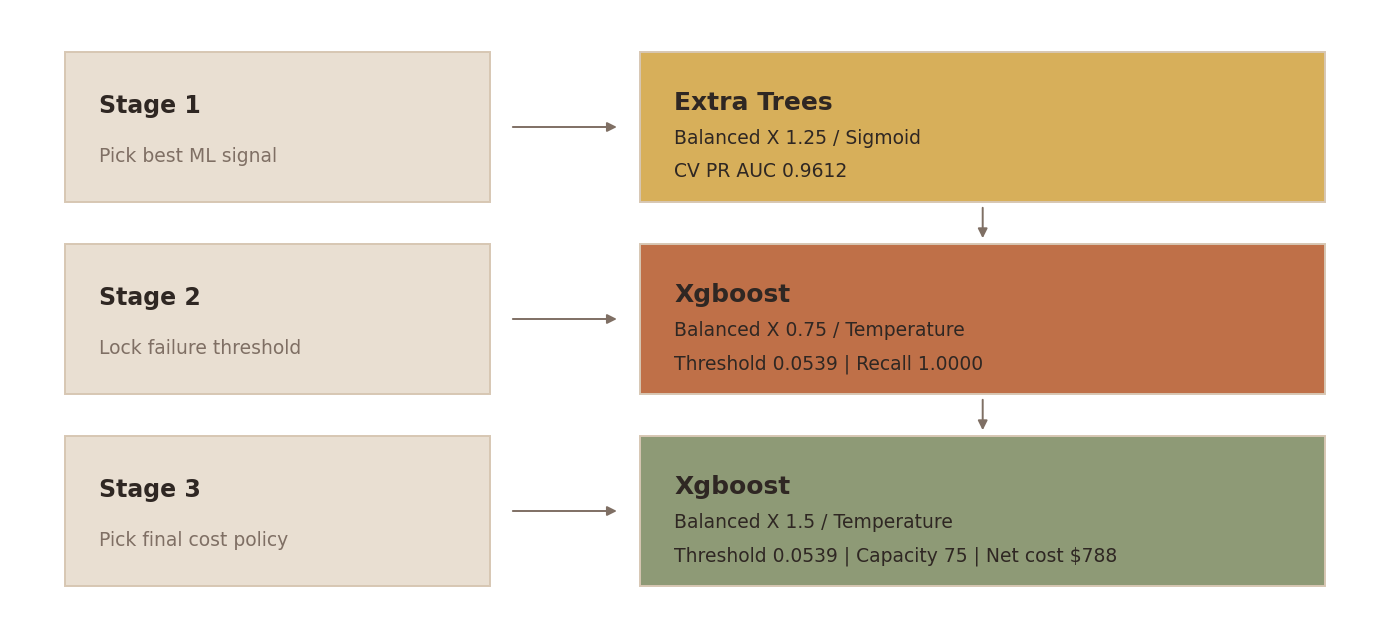

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 1. Stage 1 picks the ML signal. Stage 2 locks the threshold. Stage 3 uses value, capacity, and cost to pick the final policy.</em></div>

## Inspection plan from final policy

These results use the final model, threshold, and inspection policy. No decisions change at this stage.

,Metric,Value
1,ROC AUC,0.9683
2,PR AUC,0.9555
3,Brier,0.0695
4,ECE,0.0774
5,Urgent positive value pool,98
6,Inspected today,75
7,Saved failure value,"$57,135"
8,Inspection cost,$750
9,Missed loss,$36
10,Net cost,$786


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 5. Final test results under the fixed inspection policy. Lower net cost is better. Higher precision means fewer unnecessary checks. Higher recall means more failures caught.</em></div>

### Machine inspection decisions

,Action,Rows,Percent
1,Urgent inspection,75,52.8%
2,"Positive value, deferred due to capacity",23,16.2%
3,Urgent but low expected value (not inspected),14,9.9%
4,Monitor,30,21.1%


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 6. Final inspection decisions. Percent shows each decision’s share of the test set.</em></div>

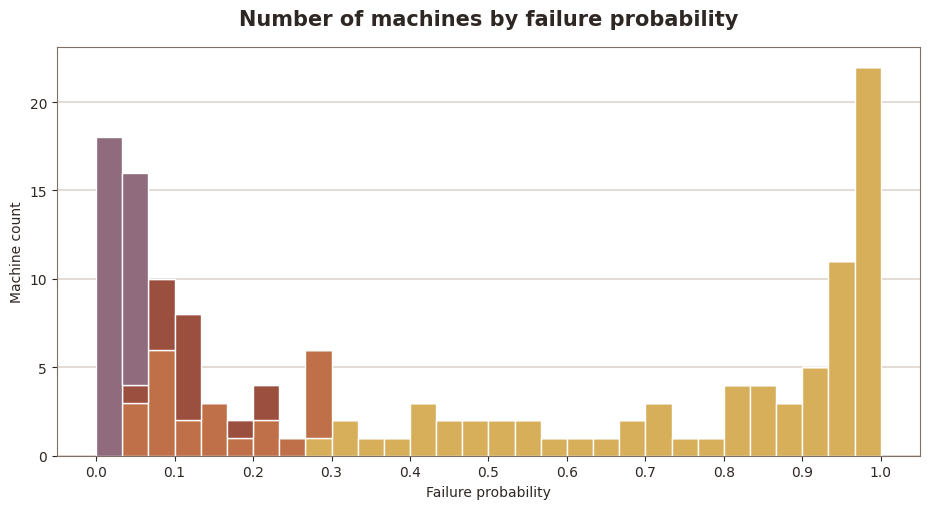

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 2. <span style='display:inline-block;width:11px;height:11px;background:#D7AF5A;border-radius:2px;'></span> Urgent inspection; <span style='display:inline-block;width:11px;height:11px;background:#BF7048;border-radius:2px;'></span> Positive value, deferred due to capacity; <span style='display:inline-block;width:11px;height:11px;background:#9B4F3F;border-radius:2px;'></span> Urgent but low expected value (not inspected); <span style='display:inline-block;width:11px;height:11px;background:#8F6B7D;border-radius:2px;'></span> Monitor. Each bar counts machines by failure probability.</em></div>

## Confusion matrix

This is only the first screening step, not the final inspection decision. It only checks the first screen: which machines are sent to urgent review before value, cost, and capacity are applied.

,Machine outcome,Threshold action,Machines,Percent of outcome
1,Failed machine,Sent to urgent,59,100%
2,Failed machine,Sent to monitor,0,0%
3,Healthy machine,Sent to urgent,53,64%
4,Healthy machine,Sent to monitor,30,36%


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 7. The locked threshold caught all 59 failed machines, so it is strong for failure capture. It also pulled in 53 healthy machines, so the next step uses value, cost, and capacity to choose what to inspect.</em></div>

...

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 11. Leakage check. Pass means no test information was used to choose the model, threshold, value rule, capacity, or policy.</em></div>

## Final interpretation

Final policy: Xgboost, Balanced X 1.5, Temperature calibration. Threshold is 0.0539, capacity is 75, and validation net cost is $788.

On test: inspect 75 machines from 98 positive value urgent machines. Net cost is $786, precision is 0.773, and failure recall is 0.983.

Bottom line: Stage 1 finds signal, Stage 2 locks the failure threshold, and Stage 3 chooses the lowest cost policy under capacity.

In [2]:
# =========================
# CELL 2 v9 - ultra lean, fixed human text preserved
# =========================
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
try:
    from IPython.display import display, Markdown
except Exception:
    display, Markdown = print, str

FILES = dict(candidate='candidate_results.csv', stage1='stage1_ml_quality_results.csv', stage2='stage2_threshold_capture_results.csv', stage3='stage3_final_policy_results.csv', summary='locked_test_summary.csv', queue='locked_test_queue.csv', confusion='locked_test_confusion_matrix.csv', feature_importance='winning_model_feature_importance.csv', threshold_stability='threshold_stability_check.csv', baseline='baseline_comparison.csv', cost_sensitivity='cost_recovery_sensitivity.csv', leakage_check='leakage_check.csv')
PATHS = {k: Path('/kaggle/working') / v for k, v in FILES.items()}
DATA = {k: pd.read_csv(v) for k, v in PATHS.items()}
candidate_df, stage1_df, stage2_df, stage3_df = (DATA[k] for k in 'candidate stage1 stage2 stage3'.split())
summary_df, queue_df, confusion_df = (DATA[k] for k in 'summary queue confusion'.split())
feature_importance_df, threshold_stability_df = (DATA[k] for k in 'feature_importance threshold_stability'.split())
baseline_df, cost_sensitivity_df, leakage_check_df = (DATA[k] for k in 'baseline cost_sensitivity leakage_check'.split())
summary_row = summary_df.iloc[0]

PALETTE = dict(sand='#E9DFD2', sand_dark='#D7C7B3', gold='#D7AF5A', rust='#BF7048', olive='#8E9A76', plum='#8F6B7D', ink='#2F2723', muted='#7F6F64', grid='#D9CEC4', inspect='#D7AF5A', backlog='#BF7048', urgent_bad='#9B4F3F', monitor='#8F6B7D')
plt.rcParams.update({k: PALETTE['ink'] for k in ['axes.labelcolor','xtick.color','ytick.color','text.color']} | {'axes.edgecolor': PALETTE['muted']})
TABLE_N = FIG_N = 0
CAL_COLS = 'calibration_method stage_3_final_calibration_method stage_3_final_calibration stage_2_threshold_winner_calibration_method stage_2_threshold_winner_calibration stage_1_ml_winner_calibration_method stage_1_ml_winner_calibration'.split()

def show_md(x): display(Markdown(x))
def cap(kind, text):
    global TABLE_N, FIG_N
    if kind == 'Table': TABLE_N += 1; n = TABLE_N
    else: FIG_N += 1; n = FIG_N
    show_md(f"<div style='margin-top:6px; color:{PALETTE['muted']}; font-size:0.95em;'><em>{kind} {n}. {text}</em></div>")
def fmt_model(x): return str(x).replace('_',' ').title()
def fmt_weight(x): x = str(x); return 'None' if x == 'none' else x.replace('_x',' x ').replace('_',' ').title()
def fmt_calibration(x): return {'none':'None','sigmoid':'Sigmoid','temperature':'Temperature'}.get(str(x), str(x).replace('_',' ').title())
def fmt_money(x): return f'${float(x):,.0f}'
def fmt_count(x): return f'{int(float(x)):,}'
def fmt_score(x): return f'{float(x):.4f}'
def cols(df, names): return [c for c in names if c in df.columns]
def val(row, names, default=np.nan): return next((row[n] for n in names if n in row.index and pd.notna(row[n])), default)
def cal(row, names=None): return fmt_calibration(val(row, names or CAL_COLS, 'Not saved') if hasattr(row, 'index') else 'Not saved')
def labels(df):
    out = df.copy()
    for s, d, f in [('model_name','model_label',fmt_model),('weight_style','weight_label',fmt_weight),('calibration_method','calibration_label',fmt_calibration)]:
        if s in out: out[d] = out[s].apply(f)
    return out
def style(df, fmt=None, gradients=(), bars=(), props=(), table_styles=None, na_rep=None):
    df = df.copy(); df.index = range(1, len(df) + 1); s = df.style
    if fmt: s = s.format({k:v for k,v in fmt.items() if k in df}, na_rep=na_rep)
    for subset, cmap in gradients:
        if c := cols(df, [subset] if isinstance(subset, str) else subset): s = s.background_gradient(subset=c, cmap=cmap, axis=None)
    for subset, color in bars:
        if c := cols(df, [subset] if isinstance(subset, str) else subset): s = s.bar(subset=c, color=color)
    for subset, kw in props: s = s.set_properties(subset=subset, **kw)
    return s.set_table_styles(table_styles) if table_styles else s
def table(df, caption='', fmt=None, gradients=(), bars=(), **kw):
    display(style(df, fmt, gradients, bars, **kw))
    if caption: cap('Table', caption)
    return df
def view(df, names, rename): return df[cols(df, names)].rename(columns={k:v for k,v in rename.items() if k in df})
def kv(rows, caption, names=('Metric','Value')): return table(pd.DataFrame(rows, columns=list(names)), caption)
def axis(ax, title=None, xlabel=None, ylabel=None, grid_axis='both'):
    if title: ax.set_title(title, pad=16, fontsize=15, fontweight='semibold', color=PALETTE['ink'])
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, color=PALETTE['grid'], linewidth=0.8, alpha=0.9); ax.set_axisbelow(True)
def done_plot(caption): plt.tight_layout(); plt.show(); cap('Figure', caption)
def report_table(df, spec, ratio=None, caption='', fmt=None, gradient=None, bar=None):
    out = view(labels(df).head(10), spec[0], spec[1])
    if ratio: out[ratio[0]] = 1 - out[ratio[1]] / out[ratio[1]].max()
    return table(out, caption, fmt, [(gradient, 'YlOrBr_r' if gradient == 'Overfit gap' else 'YlOrBr')] if gradient else (), [(bar, PALETTE['gold'])] if bar else ())

usable = candidate_df[candidate_df['fit_error'].fillna('').eq('')].copy().reset_index(drop=True)
inspect_cost_value, base_missed_value, recovery_value = val(summary_row, ['inspect_cost','row_check_cost']), val(summary_row, ['base_missed_failure_cost','missed_failure_cost']), val(summary_row, ['row_value_recovery_rate'], 1.0)
show_md('# Machine Risk Triage: Staged ML to Row Value Policy'); show_md('I use model failure predictions from machine sensor data to decide which machines to inspect today.')

show_md('## Setup')
setup_rows = [['Rows','Independent machine observations'],['Target','fail'],['Split','Train / validation / test, about 70 / 15 / 15'],['Check cost',fmt_money(inspect_cost_value)],['Missed failure cost',fmt_money(base_missed_value)],['Recovery rate',fmt_score(recovery_value)],['Cost source','Scania APS proxy, not measured project costs'],['Value rule','Severity multipliers learned on train, then applied forward'],['Candidate grid',f'{len(usable)} model-weight-calibration setups'],['Calibration methods',', '.join(sorted(candidate_df['calibration_method'].dropna().astype(str).unique())) if 'calibration_method' in candidate_df else 'Not saved']]
for c, name, f in [('row_value_features_used','Value features',str),('row_value_train_base_failure_rate','Train failure rate',fmt_score)]:
    if c in summary_row.index: setup_rows.append([name, f(summary_row[c])])
table(pd.DataFrame(setup_rows, columns=['Item','Notebook choice']), 'Setup summary. Cost uses Scania proxy values: USD 10 for an unnecessary check and USD 500 for a missed faulty machine. Recovery rate is a modeling assumption.')

show_md('## Stage 1: Selected ML model'); show_md('Stage 1 looks only at ML signal quality. It does not use cost, capacity, threshold locking, or row value.')
stage_spec = (['model_label','weight_label','calibration_label','cv_pr_auc_mean','validation_pr_auc','validation_brier','validation_ece','overfit_pr_auc_gap'], {'model_label':'Model','weight_label':'Weight','calibration_label':'Calibration','cv_pr_auc_mean':'CV PR AUC','validation_pr_auc':'Validation PR AUC','validation_brier':'Brier','validation_ece':'ECE','overfit_pr_auc_gap':'Overfit gap'})
report_table(stage1_df, stage_spec, ('Loss vs best','CV PR AUC'), 'Stage 1 ranking. Higher PR AUC is better. Loss vs best shows how much performance is lost compared with the top model. 0% means no loss.', {'CV PR AUC':'{:.3f}','Validation PR AUC':'{:.3f}','Brier':'{:.3f}','ECE':'{:.3f}','Overfit gap':'{:.3f}','Loss vs best':'{:.2%}'}, 'Overfit gap', 'Loss vs best')
s1 = stage1_df.iloc[0]; show_md(f"Stage 1 selected model: {fmt_model(s1['model_name'])} with {fmt_weight(s1['weight_style'])} and {cal(s1)} calibration. CV PR AUC mean is {float(s1['cv_pr_auc_mean']):.4f}.")

show_md('## Stage 2: Selected machine urgency threshold'); show_md('Stage 2 picks a threshold that aims to catch all failures on validation. Since all top setups catch every failure, the goal is to minimize unnecessary checks on healthy machines.')
stage2_view = view(labels(stage2_df).head(10), ['model_label','weight_label','calibration_label','validation_best_threshold','validation_false_negatives','validation_selected_count','validation_precision','validation_pr_auc','validation_brier','validation_ece'], {'model_label':'Model','weight_label':'Weight','calibration_label':'Calibration','validation_best_threshold':'Threshold','validation_false_negatives':'Missed failures','validation_selected_count':'Sent to urgent','validation_precision':'Failures in urgent queue (%)','validation_pr_auc':'PR AUC','validation_brier':'Brier','validation_ece':'ECE'})
stage2_view['Extra healthy machines sent to urgent'] = stage2_view['Sent to urgent'] - stage2_view['Sent to urgent'].min()
table(stage2_view, 'All setups catch every failure. Extra healthy machines sent to urgent shows how many extra healthy machines each setup sends to urgent review compared with the cleanest threshold. Lower is better; 0 means least extra work.', {'Threshold':'{:.3f}','Failures in urgent queue (%)':'{:.1%}','PR AUC':'{:.3f}','Brier':'{:.3f}','ECE':'{:.3f}','Extra healthy machines sent to urgent':'{:.0f}'}, [('Extra healthy machines sent to urgent','OrRd')], [('Failures in urgent queue (%)', PALETTE['gold'])])
s2 = stage2_df.iloc[0]; locked_threshold = float(s2['validation_best_threshold']); show_md(f"Stage 2 selected threshold: {fmt_model(s2['model_name'])} with {fmt_weight(s2['weight_style'])} and {cal(s2)} calibration. Threshold {locked_threshold:.4f}.")

show_md('## Stage 3: Final inspection policy (fixed for deployment)')
stage3_view = view(labels(stage3_df).head(10), ['model_label','weight_label','calibration_label','expected_net_value_sum','net_cost','net_value','urgent_pool','locked_capacity','today_precision','total_failure_recall_after_capacity'], {'model_label':'Model','weight_label':'Weight','calibration_label':'Calibration','expected_net_value_sum':'Expected value','net_cost':'Net cost','net_value':'Net value','urgent_pool':'Urgent pool','locked_capacity':'Capacity','today_precision':'Precision','total_failure_recall_after_capacity':'Recall'})
stage3_view['Value loss vs best'] = 1 - stage3_view['Expected value'] / stage3_view['Expected value'].max(); stage3_view['$ loss vs best'] = stage3_view['Expected value'].max() - stage3_view['Expected value']
table(stage3_view, 'Stage 3 ranking. Higher expected value means more savings after costs. Value loss vs best shows how much value you lose if you do not pick the top setup. 0% means best. Small values mean almost no difference.', {'Expected value':'${:,.0f}','Net cost':'${:,.0f}','Net value':'${:,.0f}','Urgent pool':'{:.0f}','Capacity':'{:.0f}','Precision':'{:.3f}','Recall':'{:.3f}','Value loss vs best':'{:.1%}','$ loss vs best':'${:,.0f}'}, [('Expected value','YlOrBr')], [('Value loss vs best', PALETTE['gold'])])
s3 = stage3_df.iloc[0]; show_md(f"Stage 3 final inspection policy (fixed for deployment): {fmt_model(s3['model_name'])} with {fmt_weight(s3['weight_style'])} and {cal(s3)} calibration. Threshold {float(s3['locked_threshold_from_stage_2']):.4f}, capacity {int(s3['locked_capacity']):,}, validation net cost {fmt_money(s3['net_cost'])}.")

show_md('## Staged decision path')
fig, ax = plt.subplots(figsize=(14, 6.3)); ax.set(xlim=(0, 1), ylim=(0, 1)); ax.axis('off')
L, R, LW, RW, BH = 0.04, 0.46, 0.31, 0.50, 0.25
left = [('Stage 1','Pick best ML signal'),('Stage 2','Lock failure threshold'),('Stage 3','Pick final cost policy')]
right = [(fmt_model(summary_row['stage_1_ml_winner_model']), f"{fmt_weight(summary_row['stage_1_ml_winner_weight'])} / {cal(summary_row, ['stage_1_ml_winner_calibration_method','stage_1_ml_winner_calibration'])}", f"CV PR AUC {float(summary_row['stage_1_cv_pr_auc_mean']):.4f}"), (fmt_model(summary_row['stage_2_threshold_winner_model']), f"{fmt_weight(summary_row['stage_2_threshold_winner_weight'])} / {cal(summary_row, ['stage_2_threshold_winner_calibration_method','stage_2_threshold_winner_calibration'])}", f"Threshold {float(summary_row['stage_2_locked_threshold']):.4f} | Recall {float(summary_row['stage_2_validation_recall']):.4f}"), (fmt_model(summary_row['stage_3_final_model']), f"{fmt_weight(summary_row['stage_3_final_weight'])} / {cal(summary_row, ['stage_3_final_calibration_method','stage_3_final_calibration'])}", f"Threshold {float(summary_row['stage_3_locked_threshold']):.4f} | Capacity {int(summary_row['stage_3_locked_capacity']):,} | Net cost {fmt_money(summary_row['stage_3_validation_net_cost'])}")]
for i, y in enumerate([0.68, 0.36, 0.04]):
    ax.add_patch(Rectangle((L,y), LW,BH, facecolor=PALETTE['sand'], edgecolor=PALETTE['sand_dark'], linewidth=1.4)); ax.add_patch(Rectangle((R,y), RW,BH, facecolor=[PALETTE['gold'], PALETTE['rust'], PALETTE['olive']][i], edgecolor=PALETTE['sand_dark'], linewidth=1.4))
    for x, txt, fs, fw, col, yy in [(L+.025,left[i][0],17,'semibold',PALETTE['ink'],.160),(L+.025,left[i][1],13.5,None,PALETTE['muted'],.075),(R+.025,right[i][0],18,'semibold',PALETTE['ink'],.165),(R+.025,right[i][1],13.5,None,PALETTE['ink'],.105),(R+.025,right[i][2],13.5,None,PALETTE['ink'],.050)]: ax.text(x, y+yy, txt, ha='left', va='center', fontsize=fs, fontweight=fw, color=col)
    ax.add_patch(FancyArrowPatch((L+LW+.015, y+BH/2), (R-.015, y+BH/2), arrowstyle='-|>', mutation_scale=14, linewidth=1.4, color=PALETTE['muted']))
for a,b in [(0.675,0.615),(0.355,0.295)]: ax.add_patch(FancyArrowPatch((R+RW/2,a),(R+RW/2,b), arrowstyle='-|>', mutation_scale=14, linewidth=1.4, color=PALETTE['muted']))
done_plot('Stage 1 picks the ML signal. Stage 2 locks the threshold. Stage 3 uses value, capacity, and cost to pick the final policy.')

show_md('## Inspection plan from final policy'); show_md('These results use the final model, threshold, and inspection policy. No decisions change at this stage.')
action_order = 'inspect_now backlog_positive_value urgent_negative_value monitor'.split(); action_colors = dict(zip(action_order, [PALETTE['inspect'], PALETTE['backlog'], PALETTE['urgent_bad'], PALETTE['monitor']])); action_labels = dict(zip(action_order, ['Urgent inspection','Positive value, deferred due to capacity','Urgent but low expected value (not inspected)','Monitor']))
action_summary = queue_df['action'].value_counts(dropna=False).reindex(action_order, fill_value=0).rename_axis('Action').reset_index(name='Rows'); action_summary['Action'] = action_summary['Action'].replace(action_labels); action_summary['Percent'] = action_summary['Rows'] / max(len(queue_df), 1)
test_keys = [('ROC AUC','test_roc_auc',fmt_score),('PR AUC','test_pr_auc',fmt_score),('Brier','test_brier',fmt_score),('ECE','test_ece',fmt_score),('Urgent positive value pool','test_urgent_pool',fmt_count),('Inspected today','test_inspected_today',fmt_count),('Inspection cost','test_base_inspect_cost',fmt_money),('Missed loss','test_missed_failure_cost',fmt_money),('Net cost','test_net_cost',fmt_money),('Precision today','test_today_precision',fmt_score),('Failure recall after capacity','test_total_failure_recall_after_capacity',fmt_score)]
test_rows = [[name, f(summary_row[key])] for name, key, f in test_keys]
test_rows.insert(6, ['Saved failure value', fmt_money(val(summary_row, ['test_saved_failure_value'], 0.0))]); test_rows.insert(10, ['Net value', fmt_money(val(summary_row, ['test_net_value'], np.nan))])
if 'test_savings_vs_inspect_none' in summary_row.index: test_rows.append(['Savings vs inspect none', fmt_money(summary_row['test_savings_vs_inspect_none'])])
kv(test_rows, 'Final test results under the fixed inspection policy. Lower net cost is better. Higher precision means fewer unnecessary checks. Higher recall means more failures caught.'); show_md('### Machine inspection decisions'); table(action_summary, 'Final inspection decisions. Percent shows each decision’s share of the test set.', {'Percent':'{:.1%}'})
fig, ax = plt.subplots(figsize=(9.4, 5.2)); plot_data = [(queue_df.loc[queue_df['action'].eq(a), 'predicted_failure_probability'].astype(float).values, action_colors[a]) for a in action_order]; plot_data = [(v,c) for v,c in plot_data if len(v)]
if plot_data:
    ax.hist([v for v,_ in plot_data], bins=np.linspace(0,1,31), stacked=True, color=[c for _,c in plot_data], edgecolor='white', linewidth=1.0); axis(ax, 'Number of machines by failure probability', 'Failure probability', 'Machine count', 'y'); ax.set_xticks(np.arange(0,1.01,.1)); ax.grid(axis='y', color=PALETTE['grid'], linewidth=1.1, alpha=0.95)
    done_plot("<span style='display:inline-block;width:11px;height:11px;background:#D7AF5A;border-radius:2px;'></span> Urgent inspection; <span style='display:inline-block;width:11px;height:11px;background:#BF7048;border-radius:2px;'></span> Positive value, deferred due to capacity; <span style='display:inline-block;width:11px;height:11px;background:#9B4F3F;border-radius:2px;'></span> Urgent but low expected value (not inspected); <span style='display:inline-block;width:11px;height:11px;background:#8F6B7D;border-radius:2px;'></span> Monitor. Each bar counts machines by failure probability.")
else: plt.close(fig)

show_md('## Confusion matrix'); show_md('This is only the first screening step, not the final inspection decision. It only checks the first screen: which machines are sent to urgent review before value, cost, and capacity are applied.')
cm = confusion_df.pivot(index='actual_class', columns='predicted_class', values='rows').fillna(0).astype(int); fail_total, ok_total = cm.loc['fail'].sum(), cm.loc['no_fail'].sum()
conf_blocks = pd.DataFrame([['Failed machine','Sent to urgent',cm.loc['fail','urgent'],cm.loc['fail','urgent']/fail_total],['Failed machine','Sent to monitor',cm.loc['fail','monitor'],cm.loc['fail','monitor']/fail_total],['Healthy machine','Sent to urgent',cm.loc['no_fail','urgent'],cm.loc['no_fail','urgent']/ok_total],['Healthy machine','Sent to monitor',cm.loc['no_fail','monitor'],cm.loc['no_fail','monitor']/ok_total]], columns=['Machine outcome','Threshold action','Machines','Percent of outcome'])
table(conf_blocks, 'The locked threshold caught all 59 failed machines, so it is strong for failure capture. It also pulled in 53 healthy machines, so the next step uses value, cost, and capacity to choose what to inspect.', {'Machines':'{:,.0f}','Percent of outcome':'{:.0%}'}, [('Machines','YlOrBr')], [('Percent of outcome', PALETTE['gold'])])

show_md('## Threshold stability'); show_md('Cost is mostly driven by capacity, not fine threshold tuning.')
df = threshold_stability_df.copy(); df['cost_delta'] = df['threshold_cost'] - df.loc[(df['threshold_multiplier'] - 1).abs().idxmin(), 'threshold_cost']
table(df[['threshold_multiplier','threshold_cost','cost_delta']], 'Change from chosen threshold (1.0). Small shifts mean threshold tuning has little impact.', {'threshold_multiplier':'{:.2f}','threshold_cost':'${:,.0f}','cost_delta':'{:+.0f}'}, [('cost_delta','YlOrBr')])

show_md('## Cost and recovery sensitivity'); show_md('This diagnostic keeps the final model, locked threshold, locked capacity, and row value ranking fixed. It then changes inspection cost, missed failure loss, and recovery rate.')
if {'recovery_rate','capacity_net_cost'}.issubset(cost_sensitivity_df.columns):
    agg = {'min_net_cost':('capacity_net_cost','min'),'median_net_cost':('capacity_net_cost','median'),'max_net_cost':('capacity_net_cost','max')}
    for c, n, f in [('capacity_today_precision','avg_today_precision','mean'),('capacity_total_failure_recall','avg_capacity_recall','mean'),('capacity_net_value','median_net_value','median')]:
        if c in cost_sensitivity_df: agg[n] = (c, f)
    sensitivity_summary = cost_sensitivity_df.groupby('recovery_rate', as_index=False).agg(**agg)
else: sensitivity_summary = pd.DataFrame()
if 'median_net_value' in sensitivity_summary: sensitivity_summary['net_value_vs_best'] = sensitivity_summary['median_net_value'] / sensitivity_summary['median_net_value'].max()
sc = cols(sensitivity_summary, ['recovery_rate','min_net_cost','median_net_cost','max_net_cost','avg_today_precision','avg_capacity_recall','median_net_value','net_value_vs_best']); sfmt = {c:'${:,.0f}' for c in ['min_net_cost','median_net_cost','max_net_cost','median_net_value'] if c in sc} | {'recovery_rate':'{:.0%}','avg_today_precision':'{:.3f}','avg_capacity_recall':'{:.3f}','net_value_vs_best':'{:.1%}'}
table(sensitivity_summary[sc], 'Sensitivity summary by recovery rate. Net cost stays stable; higher recovery gives more value. Net value vs best shows each case compared with the best tested recovery.', sfmt, [(['median_net_value','net_value_vs_best'],'YlOrBr')], [('net_value_vs_best', PALETTE['gold'])])

show_md('## Baseline comparison'); show_md('The locked policy is compared against simple alternatives. Lower net cost is better.')
baseline_show = baseline_df.copy(); baseline_show['baseline'] = baseline_show['baseline'].replace({'locked_model_threshold_valueleak_capacity':'locked policy','inspect_none':'inspect none','inspect_all':'inspect all','random_capacity_mean':'random capacity'}); baseline_show['cost_vs_worst'] = baseline_show['net_cost'] / baseline_show['net_cost'].max()
bc = cols(baseline_show, ['baseline','inspected_today','urgent_pool','net_cost','cost_vs_worst','net_value','today_precision','recall','threshold_cost_before_capacity']); bfmt = {c:'${:,.0f}' for c in ['net_cost','net_value','threshold_cost_before_capacity'] if c in bc} | {'cost_vs_worst':'{:.1%}','inspected_today':'{:.0f}','urgent_pool':'{:.0f}','today_precision':'{:.3f}','recall':'{:.3f}'}
table(baseline_show[bc], 'Baseline comparison. Cost vs worst shows each policy as a share of the most expensive option. Lower is better.', bfmt, [(['net_cost','cost_vs_worst'],'YlOrBr')], [('cost_vs_worst', PALETTE['gold'])], na_rep='N/A')

show_md('## Leakage check'); show_md('This checks that the model was picked before looking at the test set.')
n_train, n_valid, n_test = 659, 142, 142; n_total = n_train + n_valid + n_test
leak_show = pd.DataFrame([['Split data','Pass',f'Train {n_train} ({n_train/n_total:.0%}), validation {n_valid} ({n_valid/n_total:.0%}), test {n_test} ({n_test/n_total:.0%}).'],['Pick model','Pass','Stage 1 uses train/validation only. Test is not used.'],['Pick threshold','Pass','Stage 2 locks the failure cutoff before test scoring.'],['Pick policy','Pass','Stage 3 locks model, threshold, queue rule, capacity, and cost on validation.'],['Build row value rule','Pass','Machine severity groups are learned from train only, then applied forward.'],['Use test once','Pass','Test is used only at the end to report final performance.'],['Fit preprocessing','Pass','Imputation and scaling stay inside train fitted pipelines.']], columns=['Step','Status','What this means'])
leak_style = style(leak_show, props=[(['Step','Status'], {'text-align':'center'}), (['What this means'], {'text-align':'left','min-width':'620px'})], table_styles=[{'selector':'th','props':[('text-align','center')]}, {'selector':'td.col2','props':[('padding-left','24px')]}])
display(leak_style.applymap(lambda v: 'background-color: #E9DFD2' if v == 'Pass' else '', subset=['Status'])); cap('Table', 'Leakage check. Pass means no test information was used to choose the model, threshold, value rule, capacity, or policy.')

show_md('## Final interpretation')
show_md(f"Final policy: {fmt_model(summary_row['stage_3_final_model'])}, {fmt_weight(summary_row['stage_3_final_weight'])}, {cal(summary_row, ['stage_3_final_calibration_method','stage_3_final_calibration'])} calibration. Threshold is {float(summary_row['stage_3_locked_threshold']):.4f}, capacity is {int(summary_row['stage_3_locked_capacity']):,}, and validation net cost is {fmt_money(summary_row['stage_3_validation_net_cost'])}.")
show_md(f"On test: inspect {int(summary_row['test_inspected_today']):,} machines from {int(summary_row['test_urgent_pool']):,} positive value urgent machines. Net cost is {fmt_money(summary_row['test_net_cost'])}, precision is {float(summary_row['test_today_precision']):.3f}, and failure recall is {float(summary_row['test_total_failure_recall_after_capacity']):.3f}.")
show_md('Bottom line: Stage 1 finds signal, Stage 2 locks the failure threshold, and Stage 3 chooses the lowest cost policy under capacity.')